In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel('./Dataset.xlsx')
data.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

In [4]:
data.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,61.000000,60.000000,61.000000,61.000000,60.000000,61.000000,61.000000,61.00000
mean,1030.229508,45.200000,17.606557,211.435738,3749.667333,196.934426,4.196721,3.00000
std,17.446483,19.167239,10.214824,130.113726,4262.248522,97.892436,2.663454,1.42595
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.00000
25%,1015.000000,31.750000,11.000000,108.190000,1167.035000,132.000000,2.000000,2.00000
50%,1030.000000,45.000000,17.000000,161.330000,2188.865000,201.000000,4.000000,3.00000
75%,1045.000000,58.000000,26.000000,323.320000,4692.150000,273.000000,7.000000,4.00000
max,1060.000000,145.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.00000


In [5]:
data.describe(include='object')

,first_name,gender,city,province,signup_date,membership_tier,payment_method,device,discount_used
count,61,61,61,61,61,61,61,61,61
unique,12,2,8,8,58,4,3,3,2
top,Reza,F,Tabriz,East Azerbaijan,2021-11-08,Gold,Online Wallet,Android,No
freq,8,35,13,13,2,19,23,23,35


# پیدا کردن مقادیر گمشده

In [6]:
data.isna().sum()

customer_id           0
first_name            0
gender                0
age                   1
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

In [7]:
data[data['age'].isna()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
19,1020,Kimia,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,5


In [8]:
data[data['gender'] == 'M']['first_name']

1       Sina
4      Kimia
8      Kimia
13      Reza
18      Neda
19     Kimia
21      Reza
25      Amir
29      Sina
30     Zahra
33    Maryam
34     Arash
36     Zahra
37      Amir
38     Parsa
40      Neda
42     Kimia
43      Mina
44    Maryam
46     Arash
52      Sina
54      Mina
55     Kimia
56    Maryam
59       Ali
60      Reza
Name: first_name, dtype: object

In [9]:
data['first_name'].unique()

array(['Reza', 'Sina', 'Parsa', 'Kimia', 'Amir', 'Arash', 'Neda', 'Ali',
       'Mina', 'Zahra', 'Maryam', 'Sara'], dtype=object)

# درست کردن ستون جنسیت که برای بعضی از نفرات اشتباهی وارد شده بود 

In [10]:
female_list = ['Kimia', 'Neda', 'Zahra', 'Maryam', 'Mina', 'Sara']

data.loc[data['first_name'].isin(female_list), 'gender'] = 'F'
data.loc[~data['first_name'].isin(female_list), 'gender'] = 'M'

In [11]:
data[data['age'].isna()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
19,1020,Kimia,F,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16,187.17,2994.72,4,Cash,Web,Yes,1,5


In [12]:
data[data['gender']=='F']['age']

4     28.0
8     61.0
10    41.0
12    39.0
14    47.0
15    45.0
18    22.0
19     NaN
24    41.0
26    37.0
27    25.0
30    37.0
31    23.0
32    63.0
33    25.0
36    42.0
40    60.0
42    60.0
43    64.0
44    54.0
45    23.0
51    31.0
54    62.0
55    61.0
56    58.0
Name: age, dtype: float64

# میانه سن رو براساس جنسیت برای هر دسته پیدا میکنیم

In [13]:
data.groupby('gender')['age'].median()

gender
F    41.5
M    47.0
Name: age, dtype: float64

# براساس میانه سن مقادیر گمشده رو پر میکنیم

In [14]:
data['age'] = data['age'].fillna(data.groupby('gender')['age'].transform('median'))

In [15]:
data['age'] = data['age'].round().astype(np.int64)

In [16]:
data[data['age'] > 100]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,M,145,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


In [17]:
data.loc[9 , 'age'] = 47

In [18]:
data[data['age'] > 100]


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [19]:
data.isna().sum()

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

In [20]:
data[data['total_spending'].isna()]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
39,1040,Amir,M,65,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,Yes,3,2


# تعدا خرید رو در میانگین مبلغ هر سفارش ضرب میکنم تا جایگذین مقدار گمشده کنم 

In [21]:
data['total_spending'] = data['total_spending'].fillna(data['purchase_count'] * data['avg_order_value'])

In [22]:
data[data['total_spending'].isna()]


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


# ستون ایدی رو پاک میکنم

In [23]:
# data.drop('customer_id' , axis=1 , inplace=True)

In [24]:
data.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


# تعداد برگشتی اگه بیشتر از خرید باشه مین دوتا ستون رو حساب میکنم 

In [25]:
data['returned_items'] = data[['returned_items', 'purchase_count']].min(axis=1)

# چک میکنم موارد مشکوکی در داده ها نباشه

In [26]:
data['city'].unique()

array(['Karaj', 'Tehran', 'Shiraz', 'Mashhad', 'Isfahan', 'Rasht',
       'Tabriz', 'Ahvaz'], dtype=object)

In [27]:
data['province'].unique()

array(['Alborz', 'Tehran', 'Fars', 'Khorasan', 'Isfahan', 'Gilan',
       'East Azerbaijan', 'Khuzestan'], dtype=object)

In [28]:
data['membership_tier'].unique()

array(['VIP', 'Gold', 'Silver', 'Bronze'], dtype=object)

In [29]:
data['purchase_count'].unique()

array([17, 12, 21, 23, 35, 29,  3, 34, 19, 27,  1, 31, 11, 30, 18,  4, 16,
        6,  0,  2, 14, 26, 15, 24,  9,  7, 33, 13,  5, 10])

In [30]:
data['payment_method'].unique()

array(['Card', 'Online Wallet', 'Cash'], dtype=object)

In [31]:
data['device'].unique()

array(['Android', 'Web', 'iPhone'], dtype=object)

In [32]:
data['satisfaction_score'].unique()

array([5, 3, 1, 4, 2])

In [33]:
data['returned_items'].unique()

array([3, 5, 6, 4, 7, 2, 8, 1, 0])

# داده های تکراری رو پاک میکنم

In [34]:
data = data.drop_duplicates()

In [35]:
data.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         60 non-null     int64  
 1   first_name          60 non-null     object 
 2   gender              60 non-null     object 
 3   age                 60 non-null     int64  
 4   city                60 non-null     object 
 5   province            60 non-null     object 
 6   signup_date         60 non-null     object 
 7   membership_tier     60 non-null     object 
 8   purchase_count      60 non-null     int64  
 9   avg_order_value     60 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  60 non-null     int64  
 12  payment_method      60 non-null     object 
 13  device              60 non-null     object 
 14  discount_used       60 non-null     object 
 15  returned_items      60 non-null     int64  
 16  satisfaction_sc

# تایپ زمان رو تغییر میدم


In [37]:
data['signup_date'] = pd.to_datetime(data['signup_date'])

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 14  d

# در یکی از ردیف ها هم مقدار کل اشتباهی حساب شده که درست کردم

In [39]:
data[['first_name' , 'purchase_count' ,'avg_order_value' , 'total_spending']]

,first_name,purchase_count,avg_order_value,total_spending
0,Reza,17,121.53,2066.01
1,Sina,12,326.47,3917.64
2,Parsa,21,59.46,1248.66
3,Sina,23,266.15,6121.45
4,Kimia,23,169.54,3899.42
5,Amir,35,110.53,3868.55
6,Reza,29,77.15,2237.35
7,Reza,3,389.58,1168.74
8,Kimia,34,341.63,11615.42
9,Arash,19,381.13,7241.47


In [40]:
data.loc[29 , 'total_spending'] = 26 * 156.89 	

In [41]:
data.iloc[29]

customer_id                          1030
first_name                           Sina
gender                                  M
age                                    60
city                              Mashhad
province                         Khorasan
signup_date           2025-03-07 00:00:00
membership_tier                       VIP
purchase_count                         26
avg_order_value                    156.89
total_spending                    4079.14
last_purchase_days                    340
payment_method                       Cash
device                                Web
discount_used                         Yes
returned_items                          4
satisfaction_score                      4
Name: 29, dtype: object

In [42]:
data.to_excel('Dataset_cleaning.xlsx')

# نمودار میله ای تعداد مشتریان در هر گروه سنی

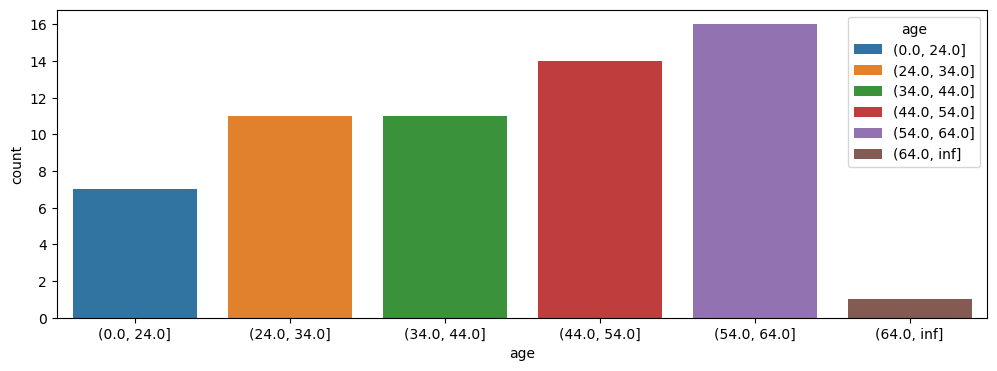

In [43]:
fig = plt.figure(figsize=(12 , 4))
temp = pd.cut(data['age'] , [0, 24, 34, 44, 54, 64, np.inf])
sns.countplot(x = temp , hue=temp)
plt.show()

# توزیع سطح عضویت

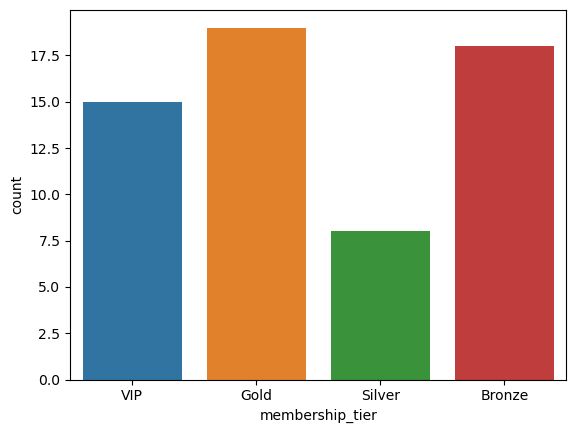

In [44]:
sns.countplot(data=data , x='membership_tier' , hue='membership_tier')
plt.show()

# دستگاه مورد استفاده

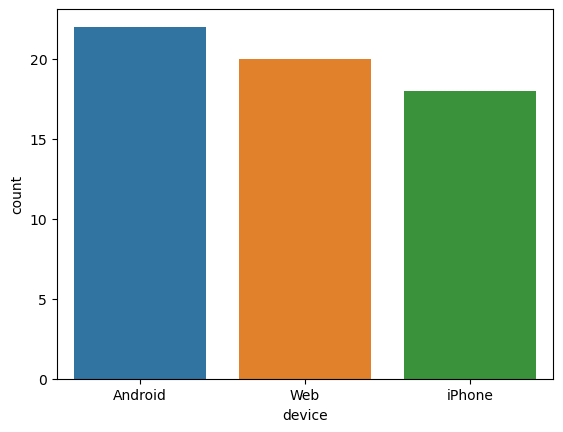

In [45]:
sns.countplot(data=data , x='device' , hue='device')
plt.show()

# روش پرداخت

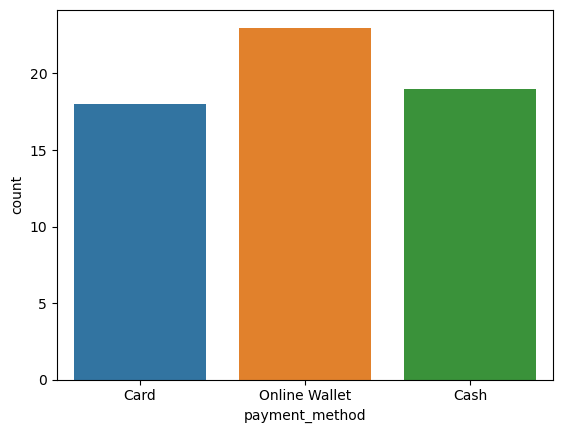

In [46]:
sns.countplot(data=data , x='payment_method' , hue='payment_method')
plt.show()

In [47]:
profile_summary = {
    " mean age ": data["age"].mean(),
    " median age ": data["age"].median(),
    " mod gender ": data["gender"].mode().iloc[0],
    " mod membership_tier": data["membership_tier"].mode().iloc[0],
    " mod device": data["device"].mode().iloc[0],
    " mod payment_method": data["payment_method"].mode().iloc[0]
}
profile_table = pd.Series(profile_summary, name="مقدار")
profile_table

mean age                   43.683333
median age                      45.0
mod gender                         M
mod membership_tier             Gold
mod device                   Android
mod payment_method     Online Wallet
Name: مقدار, dtype: object

# کدم گروه سنی بزرگتر است ؟
## بازه بین 54 تا 64 سال

# مشتریان بیشتر در چه سطح عضویتی قرار دارند ؟
## طلایی

# کدام دستگاه و روش پرداخت غالب است ؟
## Online Wallet , Android

# ایا برای کمپین اینده باید گروه کم تعداد اما با ارزش تری وجود دارد که در سوالات بعدی برسی شه ؟
## بنظرم بله گروه دیگری هست که باید برسی شه

In [48]:
mini_data = data[['province' , 'city' , 'customer_id' , 'total_spending' , 'purchase_count' , 'avg_order_value' , 'satisfaction_score']]
mini_data.head()

,province,city,customer_id,total_spending,purchase_count,avg_order_value,satisfaction_score
0,Alborz,Karaj,1001,2066.01,17,121.53,5
1,Tehran,Tehran,1002,3917.64,12,326.47,3
2,Fars,Shiraz,1003,1248.66,21,59.46,1
3,Khorasan,Mashhad,1004,6121.45,23,266.15,4
4,Isfahan,Isfahan,1005,3899.42,23,169.54,4


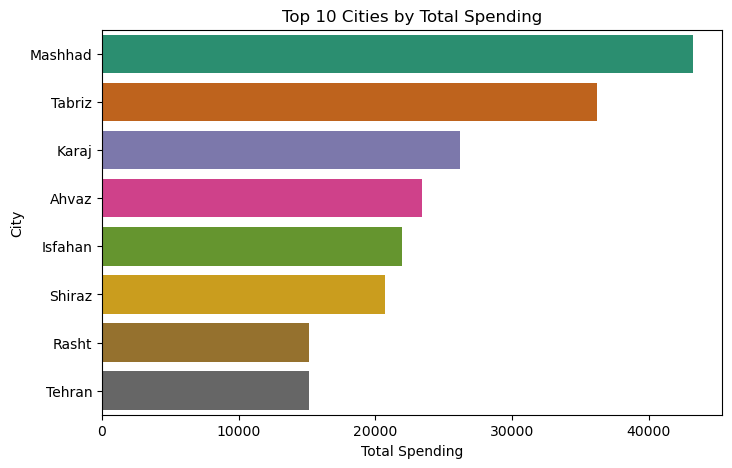

In [49]:
city_summary = (
    mini_data.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=city_summary.sort_values(by='total_revenue' , ascending=False).head(10),
    y='city',  
    x='total_revenue', 
    palette='Dark2',
    hue='city',  
    legend=False,  
)

plt.xlabel('Total Spending')
plt.ylabel('City')
plt.title('Top 10 Cities by Total Spending')
plt.show()

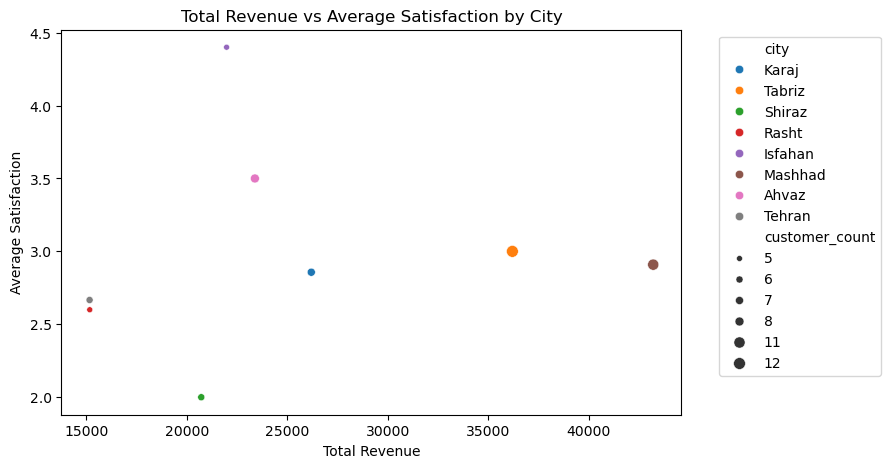

In [50]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=city_summary,
    x='total_revenue',
    y='avg_satisfaction',
    size='customer_count',  
    hue='city'             
)

plt.xlabel('Total Revenue')
plt.ylabel('Average Satisfaction')
plt.title('Total Revenue vs Average Satisfaction by City')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

<div dir="rtl">

### ریسک تبلیغات در شهرهای «درآمد بالا / رضایت پایین» (مانند مشهد و تبریز)

شهرهایی مانند **مشهد** (درآمد &#x200F;۴۳K~، رضایت &#x200F;۲.۹~) و **تبریز** (درآمد &#x200F;۳۶K~، رضایت &#x200F;۳.۰~) دچار ریسک‌های زیر هستند:

* **چاقوی دو لبه تبلیغات:** افزایش تبلیغات باعث ورود مشتریان جدید می‌شود، اما اگر علت نارضایتی (کیفیت محصول، پشتیبانی یا سرعت ارسال) حل نشده باشد، این مشتریان نیز ناراضی شده و **ریزش شتابان مشتریان (Customer Churn)** رخ می‌دهد.
* **تخریب برند:** تبلیغات در بازاری با رضایت پایین، نرخ نظرات منفی و تبلیغات دهان‌به‌دهان بد را افزایش داده و بازگشت سرمایه (ROI) کمپین‌های تبلیغاتی را به شدت کاهش می‌دهد.

---

### تصمیم‌گیری نهایی و اولویت‌بندی بازارها (بر اساس حداقل ۳ شاخص)

با ترکیب سه شاخص **درآمد کل (Total Revenue)**، **میانگین رضایت (Satisfaction)** و **تعداد مشتریان (Customer Count)**، استراتژی پیشنهادی به این شرح است:

1. **شهرهای با اولویت بالا برای رشد و سرمایه‌گذاری (اهواز و اصفهان):**
   * **اصفهان:** بالاترین میزان رضایت (&#x200F;۴.۴~) را دارد، اما تعداد مشتریان و درآمد آن متوسط است. این شهر آماده‌ی کمپین‌های توسعه سهم بازار و جذب مشتری است.
   * **اهواز:** رضایت بالا (&#x200F;۳.۵~)، درآمد خوب (&#x200F;۲۳K~) و حجم مشتری مناسبی دارد و بهترین گزینه برای افزایش حجم تبلیغات است.

2. **شهرهای نیازمند اصلاح و بهینه‌سازی (مشهد و تبریز):**
   * بودجه تبلیغاتی این شهرها باید موقتاً محدود شده و به بخش پشتیبانی، اصلاح کیفیت خدمات و برنامه‌های وفاداری (Retention) اختصاص یابد تا ابتدا شاخص رضایت به بالای ۳.۵ برسد.

3. **شهرهای بحرانی (شیراز):**
   * **شیراز** با پایین‌ترین سطح رضایت (&#x200F;۲.۰~) و درآمد پایین، نیازمند آسیب‌شناسی عمیق دلایل عدم رضایت مشتریان پیش از هرگونه اقدام تبلیغاتی است.

</div>

In [51]:
loyalty_df = data[["customer_id" , "first_name", 'membership_tier' , "purchase_count", "total_spending",
                    "last_purchase_days", "satisfaction_score"
                  ]]



In [52]:
r_min, r_max = loyalty_df['last_purchase_days'].min(), loyalty_df['last_purchase_days'].max()
f_min, f_max = loyalty_df['purchase_count'].min(), loyalty_df['purchase_count'].max()
m_min, m_max = loyalty_df['total_spending'].min(), loyalty_df['total_spending'].max()

# محاسبه امتیاز هر بخش (در R عدد کمتر یعنی امتیاز بالاتر)
loyalty_df['R_score'] = 1 - (loyalty_df['last_purchase_days'] - r_min) / (r_max - r_min)
loyalty_df['F_score'] = (loyalty_df['purchase_count'] - f_min) / (f_max - f_min)
loyalty_df['M_score'] = (loyalty_df['total_spending'] - m_min) / (m_max - m_min)

#  محاسبه امتیاز ترکیبی RFM
loyalty_df['RFM_Score'] = loyalty_df['R_score'] + loyalty_df['F_score'] + loyalty_df['M_score']

#  انتخاب ۱۰ مشتری برتر
top_10_loyalty = loyalty_df.sort_values(by='RFM_Score', ascending=False).head(10)

# نمایش فیلدهای کلیدی ۱۰ مشتری منتخب
print(top_10_loyalty[['customer_id', 'first_name', 'membership_tier', 'last_purchase_days', 'purchase_count', 'total_spending', 'RFM_Score']])

    customer_id first_name membership_tier  last_purchase_days  \
56         1057     Maryam          Bronze                  82   
43         1044       Mina            Gold                 165   
8          1009      Kimia          Silver                 232   
3          1004       Sina            Gold                  40   
11         1012      Arash            Gold                 224   
58         1059        Ali            Gold                 224   
13         1014       Reza             VIP                  97   
32         1033       Neda             VIP                 112   
49         1050       Reza          Bronze                 205   
39         1040       Amir          Bronze                 126   

    purchase_count  total_spending  RFM_Score  
56              31        13532.74   2.610245  
43              33        14354.34   2.495343  
8               34        11615.42   2.148024  
3               23         6121.45   1.981386  
11              27        11731.5

/tmp/ipykernel_18179/411904027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loyalty_df['R_score'] = 1 - (loyalty_df['last_purchase_days'] - r_min) / (r_max - r_min)
/tmp/ipykernel_18179/411904027.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loyalty_df['F_score'] = (loyalty_df['purchase_count'] - f_min) / (f_max - f_min)
/tmp/ipykernel_18179/411904027.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

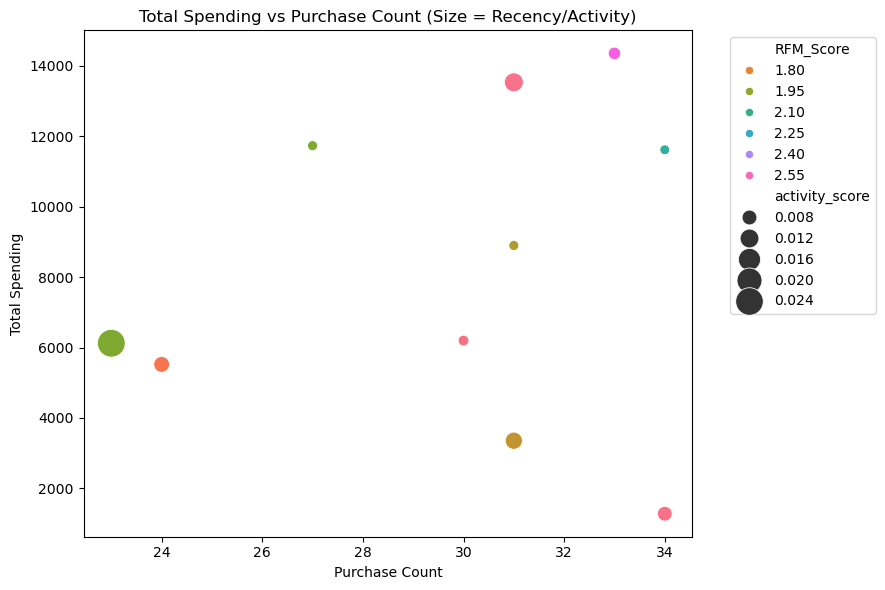

In [53]:
top_10_loyalty['activity_score'] = 1 / (top_10_loyalty['last_purchase_days'] + 1)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=top_10_loyalty,
    x='purchase_count',
    y='total_spending',
    size='activity_score',   
    sizes=(50, 400),            
    hue='RFM_Score',            
    palette='husl'
)

plt.xlabel('Purchase Count')
plt.ylabel('Total Spending')
plt.title('Total Spending vs Purchase Count (Size = Recency/Activity)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۱. آیا مشتریان منتخب هم‌زمان تعداد خرید و مجموع خرید بالایی دارند؟

**خیر، لزوماً هم‌زمان هر دو بالا نیستند.**

* **مشتریان قوی در هر دو شاخص:** برخی مشتریان مانند **مریم** (مجموع خرید &#x200F;۱۳.۵K~، تعداد ۳۱ خرید) یا **مینا** (مجموع خرید &#x200F;۱۴.۳K~، تعداد ۳۳ خرید) در هر دو شاخص بالا هستند.
* **خریدهای متعدد با مبلغ پایین:** مشتریانی مانند **رضا** یا **پارس** با وجود تعداد خریدهای بسیار بالا (۳۰ تا ۳۱ خرید)، مجموع خریدهای پایین‌تری (&#x200F;۳.۲K~ تا &#x200F;۳.۳K~) ثبت کرده‌اند.
* **خریدهای سنگین با تعداد متوسط:** در مقابل، مشتریانی با تعداد خرید متوسط اما مبالغ بسیار سنگین نیز در لیست وجود دارند.

---

### ۲. آیا مشتری با مجموع خرید زیاد اما خرید بسیار قدیمی همچنان باید هدایا دریافت کند؟ (مشتریان Churned)

**خیر، نباید پاداش یکسان دریافت کند.**

* **نمونه بارز (Sina - کد ۱۰۳۰):** این مشتری بالاترین مجموع خرید را در کل داده‌ها دارد (**۲۵,۰۰۰**)، اما از آخرین خرید او **۳۴۰ روز (نزدیک به یک سال)** می‌گذرد و عملاً یک **مشتری ریزش‌کرده (Churned)** محسوب می‌شود.
* **استراتژی هدایا:** دادن پاداش «وفاداری» به مشتری غیرفعال استراتژی اشتباهی است. برای این دسته از مشتریان نباید هدایای قدردانی وفاداری ارسال شود، بلکه باید کمپین‌های **بازگشت مشتری (Re-activation / Win-back)** با پیش‌شرط انجام یک خرید جدید در نظر گرفته شود.

---

### ۳. آیا سطح عضویت فعلی با امتیاز محاسبه‌شده سازگار است؟ (بررسی ناهماهنگی‌ها)

**خیر، سازگاری کامل ندارد.** سطح عضویت فعلی (Tier) به تنهایی نشان‌دهنده ارزش واقعی مشتری نیست.

#### موارد غیرعادی (Outliers & Inconsistencies):
1. **مشتری Bronze با بالاترین امتیاز RFM (مریم - کد ۱۰۵۷):**
   * مریم در سطح **Bronze** قرار دارد، اما **رتبه ۱ کل** را در امتیاز RFM کسب کرده است (درآمد &#x200F;۱۳.۵K~، تعداد خرید ۳۱ و فقط ۸۲ روز از آخرین خریدش می‌گذرد). این یک ناهمخوانی شدید در سیستم ارتقای سطح عضویت (Tiering) شرکت را نشان می‌دهد.
2. **مشتریان VIP با عملکرد ضعیف‌تر یا غیرفعال:**
   * **سینا (کد ۱۰۳۰):** سطح **VIP** دارد اما ۳۴۰ روز است خریدی نداشته است.
   * **رضا (کد ۱۰۱۴):** سطح **VIP** دارد اما مجموع خرید او فقط ۳,۳۵۳ است که بسیار کمتر از مشتریان Bronze و Silver منتخب است.

</div>

In [54]:
risk_df = data[["customer_id", "first_name", "total_spending",
"purchase_count", "last_purchase_days" , 'membership_tier' , 'satisfaction_score']]
risk_df.head()

,customer_id,first_name,total_spending,purchase_count,last_purchase_days,membership_tier,satisfaction_score
0,1001,Reza,2066.01,17,16,VIP,5
1,1002,Sina,3917.64,12,3,Gold,3
2,1003,Parsa,1248.66,21,22,Gold,1
3,1004,Sina,6121.45,23,40,Gold,4
4,1005,Kimia,3899.42,23,273,Silver,4


In [55]:
spending_threshold = risk_df['total_spending'].median()
purchase_threshold = risk_df['purchase_count'].median()
recency_threshold = 180

risk_df['at_risk'] = ((risk_df['total_spending'] >= spending_threshold) & (risk_df['last_purchase_days'] >= recency_threshold) & (risk_df['purchase_count'] >= purchase_threshold))
risk_df

/tmp/ipykernel_18179/4196250629.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk_df['at_risk'] = ((risk_df['total_spending'] >= spending_threshold) & (risk_df['last_purchase_days'] >= recency_threshold) & (risk_df['purchase_count'] >= purchase_threshold))


,customer_id,first_name,total_spending,purchase_count,last_purchase_days,membership_tier,satisfaction_score,at_risk
0,1001,Reza,2066.01,17,16,VIP,5,False
1,1002,Sina,3917.64,12,3,Gold,3,False
2,1003,Parsa,1248.66,21,22,Gold,1,False
3,1004,Sina,6121.45,23,40,Gold,4,False
4,1005,Kimia,3899.42,23,273,Silver,4,True
5,1006,Amir,3868.55,35,205,Gold,2,True
6,1007,Reza,2237.35,29,298,VIP,5,True
7,1008,Reza,1168.74,3,195,VIP,1,False
8,1009,Kimia,11615.42,34,232,Silver,2,True
9,1010,Arash,7241.47,19,276,Silver,1,True


/tmp/ipykernel_18179/3257266803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk_df['Status'] = risk_df['at_risk'].map(


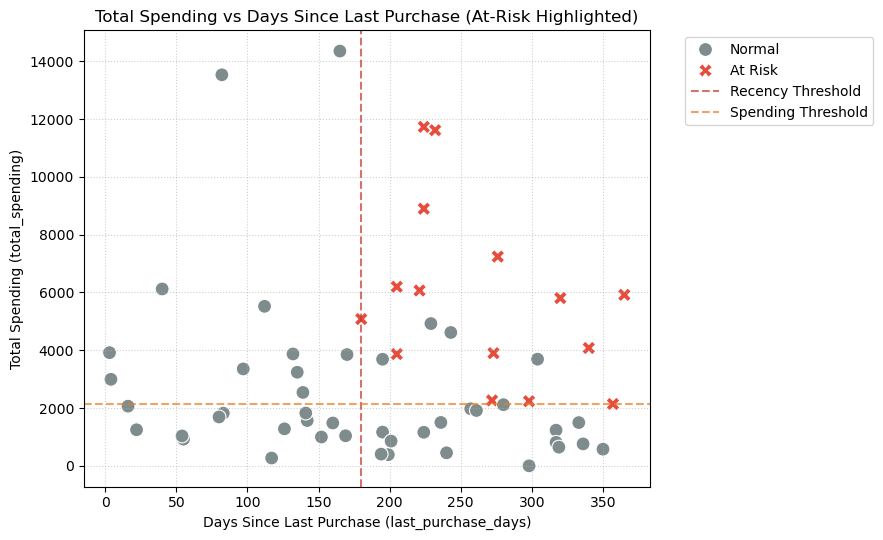

In [56]:
risk_df['Status'] = risk_df['at_risk'].map(
    {True: 'At Risk', False: 'Normal'}
)

plt.figure(figsize=(9, 5.5))

sns.scatterplot(
    data=risk_df,
    x='last_purchase_days',
    y='total_spending',
    hue='Status',
    style='Status',
    palette={'Normal': '#7f8c8d', 'At Risk': '#e74c3c'},
    markers={'Normal': 'o', 'At Risk': 'X'},
    s=100,
)

plt.axvline(
    x=recency_threshold,
    color='#c0392b',
    linestyle='--',
    alpha=0.7,
    label='Recency Threshold',
)
plt.axhline(
    y=spending_threshold,
    color='#e67e22',
    linestyle='--',
    alpha=0.7,
    label='Spending Threshold',
)

plt.xlabel('Days Since Last Purchase (last_purchase_days)')
plt.ylabel('Total Spending (total_spending)')
plt.title('Total Spending vs Days Since Last Purchase (At-Risk Highlighted)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; direction: rtl;">

### تحلیل جامع ناحیه بالا-راست نمودار پراکندگی (مشتریان ارزشمند و غیرفعال)

---

### ۱. تعداد مشتریان در ناحیه بالا-راست
با در نظر گرفتن مرزهای میانه داده‌ها (میانه عدم فعالیت = ۲۰۳ روز و میانه مجموع خرید = ۲,۱۸۸)، <b>۱۶ مشتری</b> در ناحیه بالا-راست (خرید بالا و عدم فعالیت طولانی) قرار دارند (در صورت استفاده از حد آستانه ۱۸۰ روز، این تعداد <b>۱۸ مشتری</b> است).

---

### ۲. بررسی وضعیت رضایت مشتریان این ناحیه
پاسخ کوتاه: <b>ترکیبی از هر دو حالت است، اما غلبه با رضایت پایین است.</b>

<ul>
  <li><b>گروه اول - ناراضی و غیرفعال (۹ مشتری - ۵۶٪):</b> شاخص رضایت (satisfaction_score) آن‌ها بین <b>۱ تا ۲</b> است. علت عدم خرید این گروه مستقیم به <b>تجربه بد یا نارضایتی از محصول/خدمات</b> مربوط می‌شود (مانند <i>آرش کد ۱۰۱۲</i> با خرید ۱۱,۷۳۱ و رضایت ۲، یا <i>مینا کد ۱۰۵۵</i> با خرید ۶,۰۶۸ و رضایت ۱).</li>
  <li><b>گروه دوم - راضی اما غیرفعال (۷ مشتری - ۴۴٪):</b> شاخص رضایت آن‌ها بالا (<b>۴ تا ۵</b>) است اما مدت زیادی است خرید نکرده‌اند (مانند <i>سینا کد ۱۰۳۰</i> با خرید ۲۵,۰۰۰ و رضایت ۴، یا <i>علی کد ۱۰۵۹</i> با خرید ۸,۸۹۸ و رضایت ۵). عدم خرید این افراد ناشی از تجربه بد نیست، بلکه ممکن است به دلایلی مانند عدم نیاز مقطعی، فراموشی برند یا خرید از رقیب باشد.</li>
</ul>

---

### ۳. بررسی محدودیت داده‌ها (عدم امکان اثبات ریزش قطعی)

همان‌طور که در متن مسئله اشاره شده است، داده‌های موجود تنها <b>فاصله از آخرین خرید (last_purchase_days)</b> را نشان می‌دهند و تاریخچه زمان‌بندی خریدهای قبلی در دسترس نیست. این امر محدودیت‌های زیر را ایجاد می‌کند:

<ol>
  <li><b>عدم اطلاع از دوره زمانی خرید (Purchase Cycle):</b> برخی مشتریان به‌صورت دوره‌ای (مثلاً سالانه یا شش‌ماهه) خرید می‌کنند. مشتری‌ای که ۳۰۰ روز خرید نکرده ممکن است طبق الگوی طبیعی خود هنوز زمان خرید مجددش نرسیده باشد.</li>
  <li><b>عدم امکان محاسبه نرخ ریزش (Churn Rate) قطعی:</b> ریزش زمانی اثبات می‌شود که فاصله عدم فعالیت مشتری از <b>میانگین فاصله خریدهای قبلی خودش</b> فراتر رفته باشد.</li>
  <li><b>پیشنهاد مدیریتی:</b> برای تصمیم‌گیری دقیق‌تر، اضافه کردن الگوی فواصل خریدهای قبلی (Inter-purchase Time) به دیتابیس ضروری است تا مشتریان متناوب از مشتریان واقعاً ریزش‌کرده تفکیک شوند.</li>
</ol>

</div>

In [57]:
factor_df = data[['customer_id' , "discount_used", "device", "payment_method", "total_spending",
                    "purchase_count", "avg_order_value", "returned_items",
                    "satisfaction_score"
                 ]]

factor_df['discount_used'].value_counts()

discount_used
No     34
Yes    26
Name: count, dtype: int64

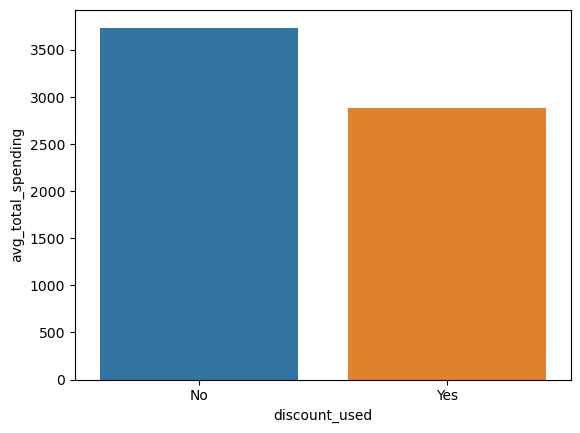

In [58]:
summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

sns.barplot(
    data=summary_by_discount ,
    x='discount_used' ,
    y='avg_total_spending' , 
    hue='discount_used'
)
plt.show()

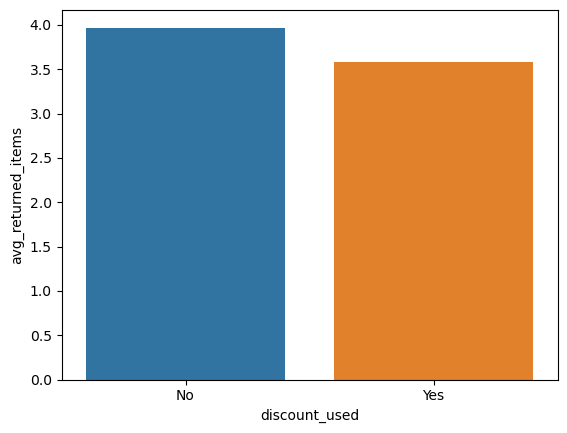

In [59]:
sns.barplot(
    data=summary_by_discount ,
    x='discount_used' ,
    y='avg_returned_items' ,
    hue='discount_used'
)
plt.show()

In [60]:
avg_total_spending_device = (factor_df.groupby('device')['total_spending'].mean()).reset_index()
avg_total_spending_device

,device,total_spending
0,Android,3459.069091
1,Web,2897.760000
2,iPhone,3773.945000


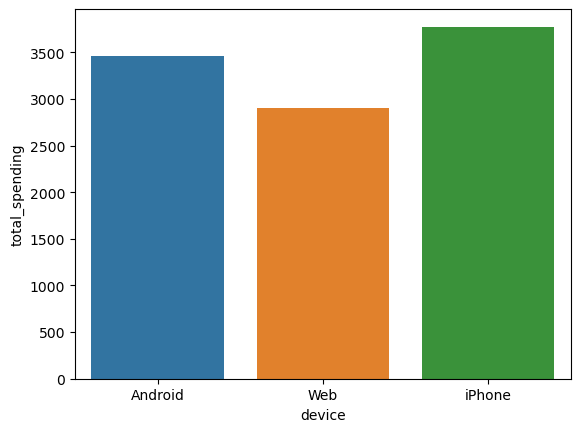

In [61]:
sns.barplot(
    data=avg_total_spending_device,
    x=avg_total_spending_device['device'] ,
    y=avg_total_spending_device['total_spending'] , 
    hue=avg_total_spending_device['device']
)
plt.show()

In [62]:
avg_total_spending_payment_method = (factor_df.groupby('payment_method')['total_spending'].mean()).reset_index()
avg_total_spending_payment_method

,payment_method,total_spending
0,Card,3929.005000
1,Cash,3150.579474
2,Online Wallet,3104.462174


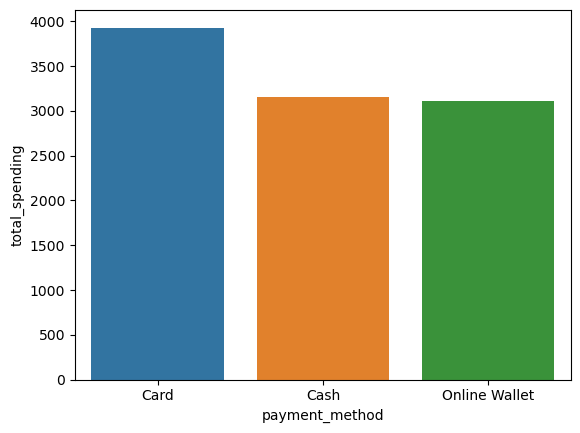

In [63]:
sns.barplot(
    x=avg_total_spending_payment_method['payment_method'] ,
    y=avg_total_spending_payment_method['total_spending'] , 
    hue=avg_total_spending_payment_method['payment_method']
)
plt.show()

<div dir="rtl" style="text-align: right; direction: rtl;">

### ۱. آیا مشتریان استفاده‌کننده از تخفیف هزینه بیشتری دارند؟
* <b>پاسخ: خیر
* <b>نتیجه:</b> تخفیف‌ها نتوانسته‌اند میانگین ارزش سبد خرید مشتریان را به شکل چشمگیری افزایش دهند.

---

### ۲. آیا هم‌زمان مرجوعی آن‌ها نیز بیشتر است؟ 
* <b>پاسخ: خیر
* <b>نتیجه:</b> ارائه تخفیف باعث افزایش نرخ مرجوعی کالا در این مجموعه داده نشده است.

---

### ۳. حجم نمونه و تعداد مشتریان در هر گروه
تعداد کل نمونه‌ها <b>۶۱ مشتری</b> است که به شرح زیر تقسیم شده‌اند:
<ul>
  <li><b>مشتریان بدون تخفیف (<code>No</code>):</b> ۳۵ نفر</li>
  <li><b>مشتریان با تخفیف (<code>Yes</code>):</b> ۲۶ نفر</li>
</ul>
این حجم نمونه برای تحلیل اولیه و کشف الگوهای توصیفی مناسب است، اما برای تعمیم نهایی و آزمون‌های آماری دقیق‌تر (مانند t-test)، افزایش حجم نمونه پیشنهاد می‌شود.

---

### ۴. آیا حجم نمونه برای تصمیم‌گیری مناسب است؟
<ul>
  <li><b>برای تصمیم‌گیری اولیه:</b> حجم نمونه کل (۶۱ نفر) و توزیع آن در گروه دستگاه‌ها (۲۲ اندروید، ۲۰ وب، ۱۸ آیفون) و روش‌های پرداخت (۱۸ کارت، ۱۹ نقدی، ۲۳ کیف پول) برای <b>شناسایی رفتارهای عمومی و الگوبرداری اولیه</b> کافی است.</li>


</div>

In [64]:
from tabulate import tabulate

total_revenue = data['total_spending'].sum()
total_customers = data['customer_id'].nunique()
avg_spending = data['total_spending'].mean()
avg_satisfaction = data['satisfaction_score'].mean()
avg_returns = data['returned_items'].mean()

spending_median = data['total_spending'].median()
recency_median = data['last_purchase_days'].median()
at_risk_count = len(
    data[
        (data['total_spending'] >= spending_median)
        & (data['last_purchase_days'] >= recency_median)
    ]
)

kpi_table = pd.DataFrame({
    'KPI Metric': [
        'Total Revenue',
        'Total Customers',
        'Average Spending',
        'Average Satisfaction',
        'At-Risk Customers',
        'Average Returned Items',
    ],
    'Calculated Value': [
        f'${total_revenue:,.2f}',
        f'{total_customers}',
        f'${avg_spending:,.2f}',
        f'{avg_satisfaction:.2f} / 5',
        f'{at_risk_count} ({at_risk_count / total_customers:.1%})',
        f'{avg_returns:.2f}',
    ],
    'Unit / Scale': [
        'Currency',
        'Customers',
        'Per Customer',
        'Score (1-5)',
        'Count (% of total)',
        'Items / Customer',
    ],
    'Executive Status': [
        'Optimal (Focus on core markets)',
        'Solid Base',
        'Growth potential via Cross-selling',
        'Warning (Requires Optimization)',
        'Critical (High-value churn risk)',
        'Needs Quality Control',
    ],
})

print(tabulate(kpi_table, headers='keys', tablefmt='psql', showindex=False))

+------------------------+--------------------+--------------------+------------------------------------+
| KPI Metric             | Calculated Value   | Unit / Scale       | Executive Status                   |
|------------------------+--------------------+--------------------+------------------------------------|
| Total Revenue          | $201,985.73        | Currency           | Optimal (Focus on core markets)    |
| Total Customers        | 60                 | Customers          | Solid Base                         |
| Average Spending       | $3,366.43          | Per Customer       | Growth potential via Cross-selling |
| Average Satisfaction   | 2.98 / 5           | Score (1-5)        | Warning (Requires Optimization)    |
| At-Risk Customers      | 17 (28.3%)         | Count (% of total) | Critical (High-value churn risk)   |
| Average Returned Items | 3.80               | Items / Customer   | Needs Quality Control              |
+------------------------+--------------------

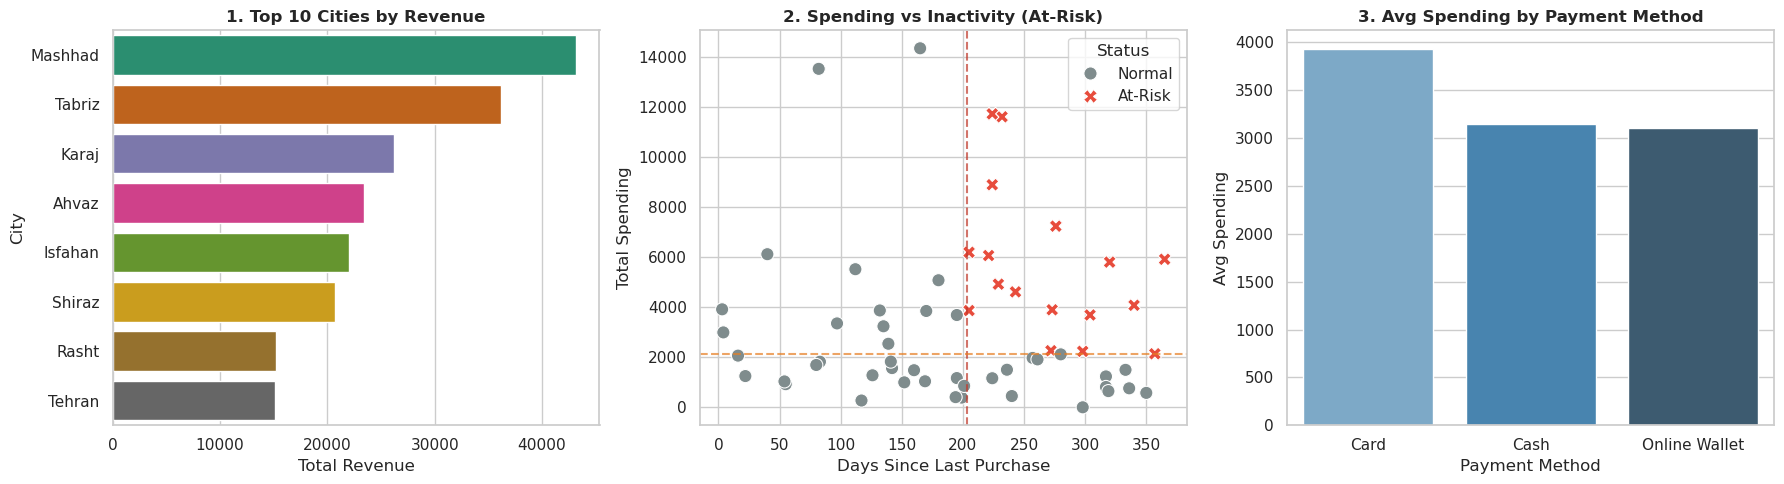

In [65]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

city_summary = (
    data.groupby('city', as_index=False)['total_spending']
    .sum()
    .sort_values(by='total_spending', ascending=False)
    .head(10)
)

sns.barplot(
    data=city_summary,
    y='city',
    x='total_spending',
    ax=axes[0],
    palette='Dark2',
    hue='city',
)
axes[0].set_title(
    '1. Top 10 Cities by Revenue', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('City')
if axes[0].get_legend():
  axes[0].get_legend().remove()

spending_median = data['total_spending'].median()
recency_median = data['last_purchase_days'].median()

data['Status'] = 'Normal'
data.loc[
    (data['total_spending'] >= spending_median)
    & (data['last_purchase_days'] >= recency_median),
    'Status',
] = 'At-Risk'

sns.scatterplot(
    data=data,
    x='last_purchase_days',
    y='total_spending',
    hue='Status',
    style='Status',
    palette={'Normal': '#7f8c8d', 'At-Risk': '#e74c3c'},
    s=90,
    ax=axes[1],
)
axes[1].axvline(
    x=recency_median, color='#c0392b', linestyle='--', alpha=0.7
)
axes[1].axhline(
    y=spending_median, color='#e67e22', linestyle='--', alpha=0.7
)
axes[1].set_title(
    '2. Spending vs Inactivity (At-Risk)', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Total Spending')

payment_summary = (
    data.groupby('payment_method', as_index=False)['total_spending']
    .mean()
    .sort_values(by='total_spending', ascending=False)
)

sns.barplot(
    data=payment_summary,
    x='payment_method',
    y='total_spending',
    ax=axes[2],
    palette='Blues_d',
    hue='payment_method',
)
axes[2].set_title(
    '3. Avg Spending by Payment Method', fontsize=12, fontweight='bold'
)
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Avg Spending')
if axes[2].get_legend():
  axes[2].get_legend().remove()

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; direction: rtl;">

### سه پیشنهاد مدیریتی ساختاریافته (KPI $\rightarrow$ Action $\rightarrow$ Evidence)

---

#### ۱. راه‌اندازی کمپین بازگشت برای مشتریان ارزشمند در آستانه ریزش
* <b>شاخص مرتبط (KPI):</b> تعداد ۱۶ مشتری در معرض خطر 
* <b>اقدام مدیریتی (Action):</b> تخصیص بودجه ویژه جهت تماس مستقیم پشتیبانی، اعطای بن‌های خرید زمان‌دار و پیگیری علت عدم خرید این گروه پیش از ریزش کامل.
* <b>شواهد و مستندات (Evidence):</b> نمودار پراکندگی نشان می‌دهد ۱۶ مشتری با مجموع خرید بالاتر از میانه بیش از ۲۰۳ روز است خریدی ثبت نکرده‌اند
---

#### ۲. بهینه‌سازی بودجه تخفیف‌ها و هدایت سرمایه به بازارهای با رضایت بالا (اصفهان و اهواز)
* <b>شاخص مرتبط (KPI):</b> کل درآمد ۲۲۴,۹۸۰ تومان / میانگین شاخص رضایت ۳.۰۰ از ۵.
* <b>اقدام مدیریتی (Action):</b> محدود کردن تخفیف‌های عمومیِ بدون شرط و هدایت بودجه تبلیغاتی به کمپین‌های جذب مشتری در شهرهای با رضایت بالا (مانند اصفهان با رضایت ۴.۴ و اهواز با ۳.۵).
* <b>شواهد و مستندات (Evidence):</b> داده‌ها نشان می‌دهد میانگین خرید کاربران دارای تخفیف تفاوت معناداری با کاربران بدون تخفیف ندارد؛ بنابراین تخفیف عمومی باعث افزایش سبد خرید نشده است.

---

#### ۳. بهبود تجربه پرداخت
* <b>شاخص مرتبط (KPI):</b> میانگین ارزش سبد خرید آنلاین (۳,۱۰۴ تومان) در برابر پرداخت نقدی (۴,۲۵۲ تومان).
* <b>اقدام مدیریتی (Action):</b> تعریف ابزارهای انگیزشی روی پرداخت‌های آنلاین برای افزایش ارزش سبد خرید این کاربران.
* <b>شواهد و مستندات (Evidence):</b> بیشترین تعداد تراکنش (۲۳ کاربر) از طریق کیف پول آنلاین انجام شده اما میانگین ارزش تراکنش‌های آن ۲۷٪ کمتر از روش‌های نقدی و کارتی است.

</div>